# Closed water mass transformation budgets in MOM6

This example uses a comprehensive set of MOM6 tracer budget diagnostics to compute a *closed* water mass transformation (WMT) budget, in which the kinematic (left-hand side) and process-based (right-hand side) estimates of the transformation agree.

### What you'll learn

- How the `xbudget` recipe encodes the structure of a model's tracer budgets, and how derived terms are reconstructed from the available diagnostics.
- How some budget terms are *redundant*, i.e. derivable in two equivalent ways from different sets of diagnostics.
- How to compute a closed WMT budget with `sum_components=True` and `group_processes=True`, and verify that the LHS and RHS agree.
- How to selectively decompose individual processes with `xbudget.BudgetQuery(...).aggregate(decompose=[...])`.

### Prerequisites

Start with [quickstart.ipynb](./quickstart.ipynb), which introduces the core `xwmt` objects, a first transformation curve, and the sign convention used throughout. This notebook assumes you are comfortable with those.

### Data

1.08 GB (shared with [north_atlantic_deep_water.ipynb](./north_atlantic_deep_water.ipynb)) · downloads once · runs in ~1 min.

## Import packages

In [1]:
import os
import warnings
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt

import xwmt
print('xwmt version', xwmt.__version__)

# Warnings are rendered with only the base name of the file that raised them. The
# default format uses the absolute path, which would bake whoever-ran-this's home
# directory into the committed output and the published documentation -- while
# still showing whether a warning came from a library or from this notebook.
warnings.formatwarning = (
    lambda msg, cat, filename, lineno, *_:
    f"{os.path.basename(filename)}:{lineno}: {cat.__name__}: {msg}\n"
)


xwmt version 0.2.1.dev50


## Load datasets and create structured grid object

The basic input for `xwmt` is an `xgcm.Grid` object that describes the structure of the underlying ocean model grid. To streamline this example, we use the helper function `load_MOM6_coarsened_diagnostics` to load the data and create the grid object.

**Note:** These diagnostics are a single annual mean for the year 2000, so the `time` dimension has length 1.

In [2]:
from load_example_model_grid import load_MOM6_coarsened_diagnostics
grid = load_MOM6_coarsened_diagnostics()
display(grid)

File 'MOM6_global_example_sigma2_budgets_v0_0_6.nc' already exists at data/MOM6_global_example_sigma2_budgets_v0_0_6.nc. Skipping download.


<xgcm.Grid>
X Axis (periodic, padding='periodic'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, padding='extend'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, padding='extend'):
  * center   sigma2_l --> outer
  * outer    sigma2_i --> center

**Note:** In addition to `grid` containing information about the static model grid, its attribute `grid._ds` points to the full dataset containing model diagnostics!

In [3]:
display(grid._ds)

<xarray.Dataset> Size: 1GB
Dimensions:                         (time_bounds: 2, sigma2_l: 74, yh: 180,
                                     xh: 240, time: 1, xq: 241, yq: 181,
                                     sigma2_i: 75)
Coordinates: (12/28)
  * time_bounds                     (time_bounds) object 16B 2000-01-01 00:00...
    time_bounds_since_init          (time_bounds) object 16B dask.array<chunksize=(2,), meta=np.ndarray>
  * sigma2_l                        (sigma2_l) float64 592B 4.246 ... 38.49
    rho2_l                          (sigma2_l) float64 592B dask.array<chunksize=(74,), meta=np.ndarray>
  * yh                              (yh) int64 1kB 0 1 2 3 4 ... 176 177 178 179
  * xh                              (xh) int64 2kB 0 1 2 3 4 ... 236 237 238 239
    ...                              ...
    geolon_c                        (yq, xq) float64 349kB dask.array<chunksize=(181, 241), meta=np.ndarray>
    geolon_u                        (yh, xq) float64 347kB dask.array<chunksize=(180, 241), meta=np.ndarray>
    wet_u                           (yh, xq) float32 174kB dask.array<chunksize=(180, 241), meta=np.ndarray>
  * yq                              (yq) int64 1kB 0 1 2 3 4 ... 177 178 179 180
  * sigma2_i                        (sigma2_i) float64 600B -3.0 11.49 ... 39.0
    rho2_i                          (sigma2_i) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
Data variables: (12/46)
    sigma2_bounds                   (time_bounds, sigma2_l, yh, xh) float64 51MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    so_bounds                       (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    thetao_bounds                   (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    thkcello_bounds                 (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    S_advection_xy                  (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    Sh_tendency_vert_remap          (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    ...                              ...
    umo                             (time, sigma2_l, yh, xq) float64 26MB dask.array<chunksize=(1, 74, 180, 241), meta=np.ndarray>
    vert_remap_h_tendency           (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    vmo                             (time, sigma2_l, yq, xh) float64 26MB dask.array<chunksize=(1, 74, 181, 240), meta=np.ndarray>
    vprec                           (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    wfo                             (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    zos                             (time, yh, xh) float64 346kB dask.array<chunksize=(1, 180, 240), meta=np.ndarray>
Attributes:
    description:  An example netcdf file containing all variables required to...
    version:      0_0_6
    doi:          10.5281/zenodo.15384910

## Part 1. Closed and comprehensive water mass transformation budgets

Each budget term belongs on one side of the water mass transformation equation, with the material derivative on the left-hand side (LHS) and the non-conservative transformation processes on the right-hand side (RHS),
\begin{equation}
\rho \frac{\text{D}\lambda}{\text{D}t} = \dot{\Lambda}.
\end{equation}

A budget is *closed* when the two sides agree. Below, we assemble every term MOM6 provides and check exactly that.

**Note:** By default, diagnostic tendencies are assumed to be integrated over the mass of each grid cell, i.e. a density-weighted volume integral.

### Comprehensive xbudget recipe

Using the optional utility package `xbudget`, we can read in a pre-configured recipe that contains comprehensive metadata about the structure of tracer budgets in MOM6. (Please feel free to contribute dictionaries for other models!) This dictionary can also be manually created.

In [4]:
from pprint import pprint

import xbudget
print('xbudget version', xbudget.__version__)

recipe = xbudget.load_preset_budget(model="MOM6")
xbudget.collect_budgets(grid, recipe)
# `collect_budgets` materializes every derived diagnostic into `grid._ds`;
# `BudgetQuery` is the queryable view over that recipe (new in xbudget 0.7).
q = xbudget.BudgetQuery(grid, recipe)

# `show_recipe` renders the recipe as a collapsible tree: each term shows the
# operation that builds it (Σ sum, × product, Δ difference) above its operands,
# with raw diagnostic names and scalar constants at the leaves. Click to expand.
xbudget.show_recipe(recipe, "heat")

xbudget version 0.8.0


xbudget recipe · heat
heat  units=W, lambda=thetao, surface_lambda=tos
├─ lhs [Σ]
│  ├─ Eulerian_tendency [×]
│  │  ├─ tracer_content_tendency_per_unit_area: opottemptend
│  │  └─ area: areacello
│  ├─ advection [Σ]
│  │  ├─ lateral [×]
│  │  │  ├─ sign: -1.
│  │  │  ├─ tracer_content_tendency_per_unit_area: T_advection_xy
│  │  │  └─ area: areacello
│  │  └─ interfacial [×]
│  │     ├─ sign: -1.
│  │     ├─ tracer_content_tendency_per_unit_area: Th_tendency_vert_remap
│  │     └─ area: areacello
│  └─ surface_ocean_flux_advective_negative_lhs [×]
│     ├─ sign: -1.
│     ├─ specific_heat_capacity: 3992. [J kg-1 K-1]
│     ├─ lambda_mass: tos
│     ├─ thickness_tendency: boundary_forcing_h_tendency
│     ├─ density: 1035. [kg m-3]
│     └─ area: areacello
└─ rhs [Σ]
   ├─ diffusion [Σ]
   │  ├─ lateral [×]
   │  │  ├─ tracer_content_tendency_per_unit_area: opottemppmdiff
   │  │  └─ area: areacello
   │  └─ interfacial [×]
   │     ├─ tracer_content_tendency_per_unit_area: opottempdiff
   │     └─ area: areacello
   ├─ surface_exchange_flux [× Σ]
   │  ├─ tracer_content_tendency_per_unit_area: boundary_forcing_heat_tendency
   │  ├─ area: areacello
   │  ├─ nonadvective [Σ]
   │  │  ├─ latent [×]
   │  │  │  ├─ tracer_content_tendency_per_unit_area: hflso
   │  │  │  └─ area: areacello
   │  │  ├─ sensible [×]
   │  │  │  ├─ tracer_content_tendency_per_unit_area: hfsso
   │  │  │  └─ area: areacello
   │  │  ├─ longwave [×]
   │  │  │  ├─ tracer_content_tendency_per_unit_area: rlntds
   │  │  │  └─ area: areacello
   │  │  └─ shortwave [×]
   │  │     ├─ tracer_content_tendency_per_unit_area: rsdoabsorb
   │  │     └─ area: areacello
   │  └─ advective [×]
   │     ├─ tracer_content_tendency_per_unit_area: heat_content_surfwater
   │     └─ area: areacello
   ├─ surface_ocean_flux_advective_negative_rhs [×]
   │  ├─ sign: -1.
   │  ├─ specific_heat_capacity: 3992. [J kg-1 K-1]
   │  ├─ lambda_mass: tos
   │  ├─ thickness_tendency: boundary_forcing_h_tendency
   │  ├─ density: 1035. [kg m-3]
   │  └─ area: areacello
   ├─ bottom_flux [×]
   │  ├─ tracer_content_tendency_per_unit_area: internal_heat_heat_tendency
   │  └─ area: areacello
   └─ frazil_ice [×]
      ├─ tracer_content_tendency_per_unit_area: frazil_heat_tendency
      └─ area: areacello

Note how this nested recipe structure allows diagnostics which are unavailable in a convenient layer-integrated form to be derived or approximated from other available variables. For example, consider the advective surface ocean heat flux, which appears in the tree above as `surface_ocean_flux_advective_negative_rhs [×]`. In the underlying dictionary it reads

```python
            "surface_ocean_flux_advective_negative_rhs": {
                "product": {
                    "sign": -1.0,
                    "specific_heat_capacity": 3992.0,
                    "lambda_mass": "tos",
                    "thickness_tendency": "boundary_forcing_h_tendency",
                    "density": 1035.0,
                    "area": "areacello"
                }
            },
```

This gives `xbudget` instructions on how to reconstruct the `surface_ocean_flux_advective_negative_rhs` tendency as a product of other terms:
\begin{equation}
-\lambda_{m}Q_{m} \text{d}A = (-1)*(c_{p}*\Theta_{m})*\big(\rho_{0}*\big[\frac{\partial h}{\partial t}\big]_{boundary}\big) * \text{d}A
\end{equation}

By calling `xbudget.collect_budgets`, every derived term is given a standardized name and lazily added to the dataset `grid._ds`. The `BudgetQuery` maps each term — addressed by its path through the budget — to that name, so we can pull the lazily-calculated term described above straight out of the dataset:

In [5]:
grid._ds[q.var(("heat", "rhs", "surface_ocean_flux_advective_negative_rhs"))]

<xarray.DataArray 'heat_rhs_surface_ocean_flux_advective_negative_rhs' (
                                                                        time: 1,
                                                                        yh: 180,
                                                                        xh: 240,
                                                                        sigma2_l: 74)> Size: 26MB
dask.array<mul, shape=(1, 180, 240, 74), dtype=float64, chunksize=(1, 180, 240, 74), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 8B 2000-07-01 00:00:00
  * yh         (yh) int64 1kB 0 1 2 3 4 5 6 7 ... 173 174 175 176 177 178 179
  * xh         (xh) int64 2kB 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
    areacello  (yh, xh) float64 346kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    deptho     (yh, xh) float32 173kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    geolat     (yh, xh) float64 346kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    geolon     (yh, xh) float64 346kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    lat        (yh, xh) float64 346kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    lon        (yh, xh) float64 346kB dask.array<chunksize=(180, 240), meta=np.ndarray>
    wet        (yh, xh) float32 173kB dask.array<chunksize=(180, 240), meta=np.ndarray>
  * sigma2_l   (sigma2_l) float64 592B 4.246 13.57 17.71 ... 37.76 37.9 38.49
    rho2_l     (sigma2_l) float64 592B dask.array<chunksize=(74,), meta=np.ndarray>
Attributes:
    provenance:    [-1.0, 3992.0, 'tos', 'boundary_forcing_h_tendency', 1035....
    xbudget_path:  ['heat', 'rhs', 'surface_ocean_flux_advective_negative_rhs']
    xbudget_op:    product
    units:         W

Expanded in full that recipe is daunting, but we don't need every term just to close the water mass transformation budget. The `BudgetQuery` collapses each budget to its highest-level terms with `.aggregate()`.

In [6]:
simple_budgets = q.aggregate()
pprint(simple_budgets, sort_dicts=False)

{'mass': {'units': 'kg s-1',
          'lambda': 'density',
          'thickness': 'thkcello',
          'lhs': {'Eulerian_tendency': 'mass_lhs_Eulerian_tendency'},
          'rhs': {'advection': 'mass_rhs_advection',
                  'surface_exchange_flux': 'mass_rhs_surface_exchange_flux'}},
 'heat': {'units': 'W',
          'lambda': 'thetao',
          'surface_lambda': 'tos',
          'lhs': {'Eulerian_tendency': 'heat_lhs_Eulerian_tendency',
                  'advection': 'heat_lhs_advection',
                  'surface_ocean_flux_advective_negative_lhs': 'heat_lhs_surface_ocean_flux_advective_negative_lhs'},
          'rhs': {'diffusion': 'heat_rhs_diffusion',
                  'surface_exchange_flux': 'heat_rhs_surface_exchange_flux',
                  'surface_ocean_flux_advective_negative_rhs': 'heat_rhs_surface_ocean_flux_advective_negative_rhs',
                  'bottom_flux': 'heat_rhs_bottom_flux',
                  'frazil_ice': 'heat_rhs_frazil_ice'}},
 'salt': {'un

### Redundancy of derived terms

Some terms in the budget, such as the water mass transformation due to surface heat fluxes, can be equivalently derived from two different sets of budget diagnostics:

In [7]:
desc = q.get_vars(("heat", "rhs", "surface_exchange_flux"))
print("As the product of the layer-integrated convergence of surface heat fluxes,")
print("multiplied with the cell area:")
print("   ", " × ".join(desc["product"]), end="\n\n")
print("Or as the sum of the individual surface heat flux components (advective and")
print("non-advective), each already the cell-area integral of a flux:")
for v in desc["sum"]:
    print("    +", v)

As the product of the layer-integrated convergence of surface heat fluxes,
multiplied with the cell area:
    boundary_forcing_heat_tendency × areacello

Or as the sum of the individual surface heat flux components (advective and
non-advective), each already the cell-area integral of a flux:
    + heat_rhs_surface_exchange_flux_nonadvective
    + heat_rhs_surface_exchange_flux_advective


We can plot these to verify that they are indeed equivalent (to machine precision):

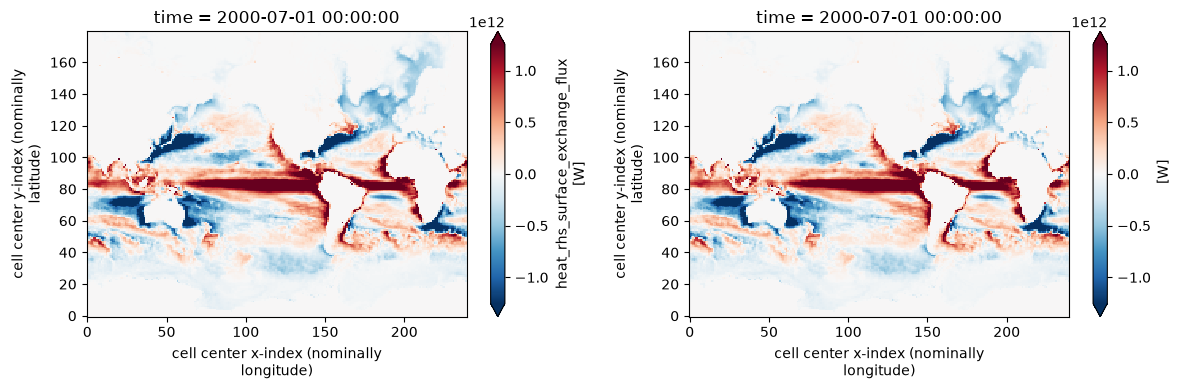

In [8]:
product_form = grid._ds[desc["var"]]              # one diagnostic, already integrated x area
sum_form = sum(grid._ds[v] for v in desc["sum"])  # sum of the individual flux components

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
product_form.sum("sigma2_l").plot(robust=True)
plt.subplot(1, 2, 2)
sum_form.sum("sigma2_l").plot(robust=True)
plt.tight_layout()

### Compute water mass transformations

Finally, we can create an instance of the core `WaterMassTransformations` class and verify that it can find all of the processes we need in the dataset.

In [9]:
wmt = xwmt.WaterMassTransformations(grid, simple_budgets)
sorted(wmt.available_processes())

['Eulerian_tendency',
 'advection',
 'bottom_flux',
 'diffusion',
 'frazil_ice',
 'surface_exchange_flux',
 'surface_ocean_flux_advective_negative_lhs',
 'surface_ocean_flux_advective_negative_rhs']

We use the `integrate_transformations` method to compute area-integrated water mass transformations in the specified coordinate (e.g. `"heat"`). Setting `sum_components=True` and `group_processes=True` collapses the many individual diagnostics into the handful of named processes above, and adds the aggregate `kinematic_transformation` (LHS) and `material_transformation` (RHS) terms that we use to check budget closure.

Recall the sign convention introduced in [quickstart.ipynb](./quickstart.ipynb): transformations are positive when they tend to increase the mass of water with tracer values less than the given threshold $\tilde{\lambda}$.

In [10]:
# xwmt's internal call to xr.merge emits a FutureWarning about changing default
# arguments; it does not affect the result here, so we silence it to keep the output readable.
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    kwargs = {"sum_components":True, "group_processes":True}
    G_temperature = wmt.integrate_transformations(
        "heat",
        bins=np.arange(-3, 35, 0.25),
        **kwargs
    ).mean('time')
    G_salinity = wmt.integrate_transformations(
        "salt",
        bins=np.arange(0, 50, 0.25),
        **kwargs
    ).mean('time')
    G_density = wmt.integrate_transformations(
        "sigma0",
        bins=np.arange(0, 40, 0.25),
        **kwargs
    ).mean('time')
    
Gs = [G_temperature, G_salinity, G_density]

wmt.py:1096: UserWarning: Process 'bottom_flux' for component salt is unavailable.
wmt.py:1096: UserWarning: Process 'frazil_ice' for component salt is unavailable.


In [11]:
for G in Gs:
    with ProgressBar():
        G.load()

[                                        ] | 0% Completed | 169.75 us

[#####                                   ] | 13% Completed | 102.02 ms

[#####                                   ] | 13% Completed | 210.81 ms

[#######################                 ] | 57% Completed | 320.14 ms

[########################################] | 100% Completed | 438.37 ms

...

[#####                                   ] | 13% Completed | 216.80 ms

[######                                  ] | 17% Completed | 323.34 ms

[############                            ] | 31% Completed | 466.23 ms

[############################            ] | 71% Completed | 576.77 ms

[########################################] | 100% Completed | 687.19 ms

Finally, we plot the WMT associated with each term and verify that our water mass transformation budgets close.

The terms span several orders of magnitude, so we give each group its own panel and its own y-axis: the LHS terms (left), the RHS processes with the LHS overlaid (middle), and the LHS$-$RHS residual (right). We convert from a mass transformation rate [kg/s] to a volume transport in Sverdrups [Sv] using a reference density $\rho_{0}$, as in the quickstart.

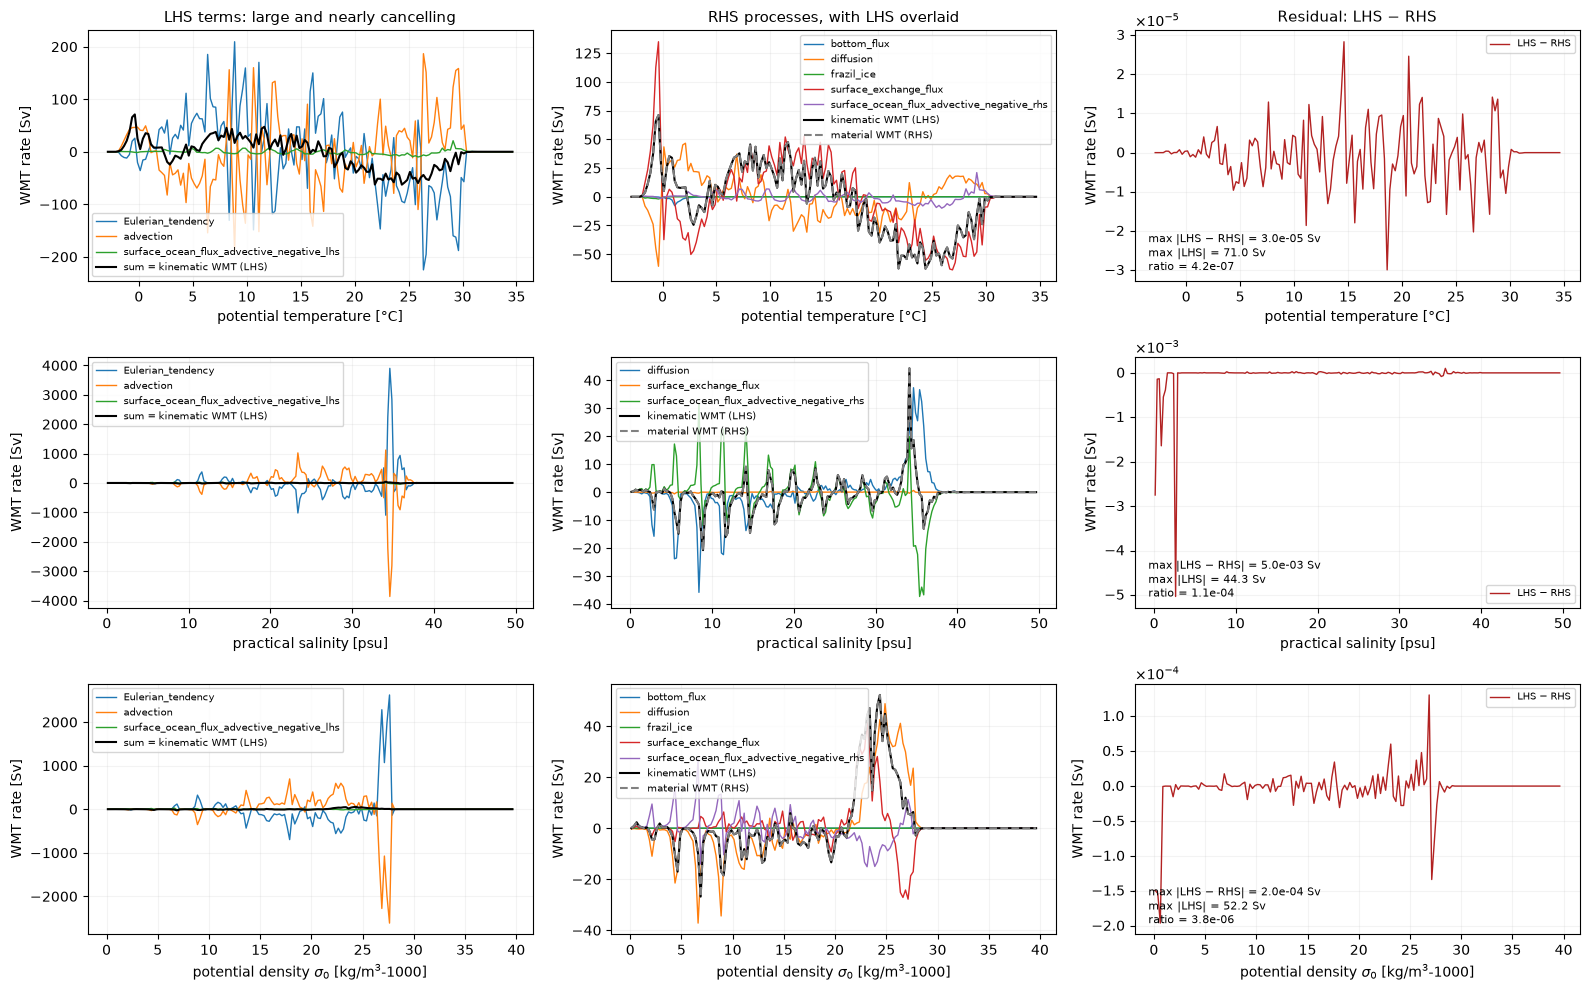

In [12]:
rho0 = 1035.
Sv = 1e-6/rho0  # convert mass transformation rate [kg/s] to volume transport [Sv]

# Split the grouped processes into the LHS (kinematic) and RHS (material) terms.
processes = sorted(wmt.available_processes())
lhs_terms = [v for v in processes if v in ("Eulerian_tendency", "advection") or v.endswith("_lhs")]
rhs_terms = [v for v in processes if v not in lhs_terms]

long_names = [
    r"potential temperature [$\degree$C]",
    r"practical salinity [psu]",
    r"potential density $\sigma_{0}$ [kg/m$^{3}$-1000]",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for i, (G, long_name) in enumerate(zip(Gs, long_names)):
    lhs, rhs = G["kinematic_transformation"], G["material_transformation"]
    residual = lhs - rhs

    # Column 1: the LHS terms, on a scale set by the two huge ones.
    ax = axes[i, 0]
    for v in lhs_terms:
        if v in G: (G[v]*Sv).plot(ax=ax, label=v, lw=1)
    (lhs*Sv).plot(ax=ax, label="sum = kinematic WMT (LHS)", color="k")

    # Column 2: the RHS processes, on a scale set by *them*, with LHS overlaid.
    ax = axes[i, 1]
    for v in rhs_terms:
        if v in G: (G[v]*Sv).plot(ax=ax, label=v, lw=1)
    (lhs*Sv).plot(ax=ax, label="kinematic WMT (LHS)", color="k")
    (rhs*Sv).plot(ax=ax, label="material WMT (RHS)", ls="--", color="grey")

    # Column 3: the residual, on a scale set by the residual itself.
    ax = axes[i, 2]
    (residual*Sv).plot(ax=ax, color="firebrick", lw=1, label="LHS $-$ RHS")
    ax.annotate(
        f"max |LHS $-$ RHS| = {float(abs(residual).max())*Sv:.1e} Sv\n"
        f"max |LHS| = {float(abs(lhs).max())*Sv:.1f} Sv\n"
        f"ratio = {float(abs(residual).max())/float(abs(lhs).max()):.1e}",
        xy=(0.03, 0.03), xycoords="axes fraction", fontsize=8, va="bottom",
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)

    for j, ax in enumerate(axes[i, :]):
        ax.set_title("")
        ax.set_xlabel(long_name)
        ax.set_ylabel("WMT rate [Sv]")
        ax.grid(True, alpha=0.15)
        ax.legend(fontsize=7, loc="best")

for ax, title in zip(axes[0, :], [
    "LHS terms: large and nearly cancelling",
    "RHS processes, with LHS overlaid",
    "Residual: LHS $-$ RHS",
]):
    ax.set_title(title, fontsize=11)
plt.tight_layout()


**The budget closes.** In the right-hand column, the residual `kinematic_transformation - material_transformation` is at most $3\times10^{-5}$ Sv (heat), $5\times10^{-3}$ Sv (salt) and $2\times10^{-4}$ Sv ($\sigma_{0}$) — a factor of $10^{4}$–$10^{6}$ smaller than the ~44-71 Sv transformations themselves. The two sides of the transformation equation agree to numerical roundoff, which is exactly the claim this notebook exists to demonstrate.

**Why the terms need three different scales.** Notice that each column above is plotted on its own y-axis, and that this is essential rather than cosmetic:

- The LHS terms `Eulerian_tendency` and `advection` reach $\pm 225$ Sv in temperature and a remarkable $\pm 3900$ Sv in salinity (and $\pm 2600$ Sv in $\sigma_{0}$, where the salt component contributes $\pm 2630$ Sv against only $\pm 198$ Sv from heat).
- Yet they very nearly cancel: their sum, the kinematic transformation, is only ~44-71 Sv. The interior ocean advects enormous amounts of tracer around, but almost all of that transport is *adiabatic* — it moves water along $\lambda$ surfaces rather than across them, and so cancels out of the transformation.
- The RHS process terms are correspondingly modest: `surface_exchange_flux` peaks at ~135 Sv in temperature, `diffusion` at ~60 Sv, and `bottom_flux` and `frazil_ice` at ~8 Sv and ~2 Sv.

This is the practical lesson: plotting every term on shared axes — as is tempting — lets the two large, nearly-cancelling LHS terms set the y-limits and squashes both the physically interesting RHS processes *and* the closure itself flat against zero. The near-cancellation between tendency and advection is a real and important feature of the circulation, but in water mass transformation theory we are ultimately interested in the RHS: the non-conservative processes that actually transform water masses.


## Part 2. Selectively decomposing budget terms

In density coordinates, there seems to be a dominant balance between the diffusive and surface fluxes terms on the RHS.

Let's break those processes down even further to gain a better understanding.

**Note:** the vertical axis of this dataset is already $\sigma_{2}$, so requesting `"sigma2"` here uses `xwmt`'s *prebinned* code path rather than binning from scratch. See [north_atlantic_deep_water.ipynb](./north_atlantic_deep_water.ipynb) for more on prebinned coordinates.

In [13]:
decomposed_budgets = q.aggregate(
    decompose=["diffusion", "surface_exchange_flux", "nonadvective"]
)
wmt_dec = xwmt.WaterMassTransformations(grid, decomposed_budgets)
sorted(wmt_dec.available_processes())

['Eulerian_tendency',
 'advection',
 'bottom_flux',
 'diffusion_interfacial',
 'diffusion_lateral',
 'frazil_ice',
 'surface_exchange_flux_advective',
 'surface_exchange_flux_evaporation',
 'surface_exchange_flux_icebergs',
 'surface_exchange_flux_nonadvective_basal',
 'surface_exchange_flux_nonadvective_latent',
 'surface_exchange_flux_nonadvective_longwave',
 'surface_exchange_flux_nonadvective_sensible',
 'surface_exchange_flux_nonadvective_shortwave',
 'surface_exchange_flux_rain_and_ice',
 'surface_exchange_flux_rivers',
 'surface_exchange_flux_sea_ice_melt',
 'surface_exchange_flux_snow',
 'surface_exchange_flux_virtual_precip_restoring',
 'surface_ocean_flux_advective_negative_lhs',
 'surface_ocean_flux_advective_negative_rhs']

`diffusion` has split into its lateral and interfacial parts, and `surface_exchange_flux` into the individual air-sea fluxes. Now compute the transformation with this finer set of terms.

We bin on the model's own `sigma2_i` interfaces rather than a uniform grid. This dataset's vertical coordinate already *is* $\sigma_{2}$, so those interfaces are the finest binning the data actually support — see the note above on the prebinned code path.

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    G_decomposed = wmt_dec.integrate_transformations(
        "sigma2",
        bins=grid._ds.sigma2_i.values,  # the model's own density interfaces
        sum_components=True,
    ).mean('time')

with ProgressBar():
    G_decomposed.load()

# The aggregate that this decomposition breaks up, on the same coordinate and the same
# bins, so the comparison in the discussion below is like-for-like.
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    G_aggregate = wmt.integrate_transformations(
        "sigma2",
        bins=grid._ds.sigma2_i.values,
        sum_components=True,
        group_processes=True,
    ).mean('time')

with ProgressBar():
    G_aggregate.load()

agg = G_aggregate["surface_exchange_flux"]*Sv
print(f"aggregate surface_exchange_flux spans "
      f"{float(agg.min()):.1f} to {float(agg.max()):.1f} Sv")

# Derive the term list from the result rather than hardcoding it: the names depend
# on what was passed to `decompose=`, and a hardcoded list goes stale silently.
# Same LHS rule as Part 1, so a future preset adding another `*_lhs` term is still
# classified correctly.
def is_lhs(v):
    return v in ("Eulerian_tendency", "advection") or v.endswith("_lhs")

processes = [p for p in sorted(wmt_dec.available_processes())
             if not is_lhs(p) and p in G_decomposed]

# Report anything advertised but missing rather than dropping it silently, which is
# what hid a bug here previously. For this preset the missing terms all belong to the
# *mass* budget alone (rivers, icebergs, evaporation, ...) and carry no heat or salt
# tendency, so they cannot appear for a density lambda -- but the message states what
# was observed, not why, so a genuinely missing process would not be explained away.
absent = [p for p in sorted(wmt_dec.available_processes())
          if not is_lhs(p) and p not in G_decomposed]
print(f"{len(processes)} RHS processes to plot")
print(f"advertised by available_processes() but absent for this lambda: {absent}")

[                                        ] | 0% Completed | 80.38 us

[###                                     ] | 7% Completed | 103.11 ms

[###                                     ] | 7% Completed | 213.47 ms

[####                                    ] | 11% Completed | 314.19 ms

[#####                                   ] | 13% Completed | 421.09 ms

...

[##########################              ] | 67% Completed | 774.05 ms

[##########################              ] | 67% Completed | 880.87 ms

[################################        ] | 80% Completed | 981.86 ms

[########################################] | 100% Completed | 1.09 s

aggregate surface_exchange_flux spans -55.3 to 59.1 Sv
11 RHS processes to plot
advertised by available_processes() but absent for this lambda: ['surface_exchange_flux_evaporation', 'surface_exchange_flux_icebergs', 'surface_exchange_flux_rain_and_ice', 'surface_exchange_flux_rivers', 'surface_exchange_flux_sea_ice_melt', 'surface_exchange_flux_snow', 'surface_exchange_flux_virtual_precip_restoring']


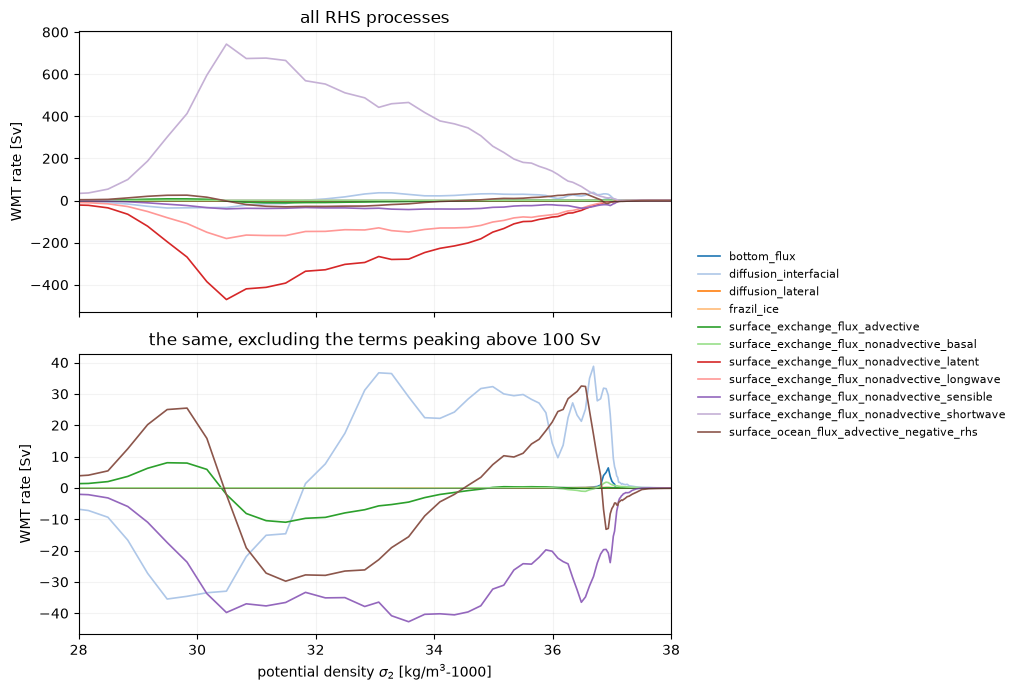

In [15]:
long_name = r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]"

# Part 1's lesson applies again: a few large terms would flatten the rest on a
# shared axis, so the smaller processes get their own panel. Colors are fixed per
# process so the two panels agree and one legend serves both.
peak = {v: float(abs(G_decomposed[v]).max())*Sv for v in processes}
secondary = [v for v in processes if peak[v] <= 100.]
colors = dict(zip(processes, plt.cm.tab20(np.arange(len(processes)))))

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for v in processes:
    (G_decomposed[v]*Sv).plot(ax=axes[0], label=v, lw=1.2, color=colors[v])
axes[0].set_title("all RHS processes")
for v in secondary:
    (G_decomposed[v]*Sv).plot(ax=axes[1], label=v, lw=1.2, color=colors[v])
axes[1].set_title("the same, excluding the terms peaking above 100 Sv")

for ax in axes:
    ax.grid(True, alpha=0.15)
    ax.set_ylabel("WMT rate [Sv]")
    ax.axhline(0., color="k", lw=0.6, alpha=0.4)
axes[1].set_xlim(28., 38.)
axes[0].set_xlabel("")
axes[1].set_xlabel(long_name)
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left",
           bbox_to_anchor=(0.99, 0.5), fontsize=8, frameon=False)
fig.tight_layout()

The decomposition answers a question Part 1 could not. Aggregated, `surface_exchange_flux` spans roughly $-55$ to $+59$ Sv in this coordinate — but that is the small residual of two very large opposing fluxes. Shortwave heating lightens water at up to $+742$ Sv, while latent and longwave cooling densify it at up to $-470$ and $-180$ Sv. The aggregate is more than an order of magnitude smaller than its own largest component.

The second panel shows what survives underneath. `diffusion_interfacial` — mixing across density surfaces — runs from $-35$ to $+39$ Sv and, unlike the surface terms, stays active across the whole density range rather than concentrating near $\sigma_{2} \approx 30$. `diffusion_lateral` is identically zero: this configuration does provide the lateral diffusive tendency diagnostic, but every value in it is zero, so all of the diffusion in Part 1's figure was interfacial.

That is the general lesson of decomposing a budget: an aggregate term being small does not mean its constituents are, and which process appears to dominate depends on how finely you look.

### Where to next?

To see *where* these transformations happen, rather than just their distribution in $\lambda$-space, see [north_atlantic_deep_water.ipynb](./north_atlantic_deep_water.ipynb), which uses `map_transformations` to map the spatial patterns of surface-forced transformation and build a North Atlantic Deep Water case study.